# Imports necessários

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from pathlib import Path

# from matplotlib_inline.backend_inline import set_matplotlib_formats
# # Define o formato global para SVG
# set_matplotlib_formats('svg')

# Configurações

In [2]:
# Reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Caminhos do projeto
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "cs-training.csv"

# Configurações do Pandas
pd.set_option("display.width", 1000)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Configurações dos gráficos
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

# Ignorar warnings desnecessários
warnings.filterwarnings("ignore")

# Obtendo dados

In [3]:
df = pd.read_csv(DATA_PATH, sep=',')

rename_columns = {
    "Unnamed: 0": "id",
    "SeriousDlqin2yrs": "inadimplente",
    "RevolvingUtilizationOfUnsecuredLines": "utilizacao_credito_rotativo",
    "age": "idade",
    "NumberOfTime30-59DaysPastDueNotWorse": "num_atrasos_30_59_dias",
    "DebtRatio": "indice_endividamento",
    "MonthlyIncome": "renda_mensal",
    "NumberOfOpenCreditLinesAndLoans": "num_linhas_credito",
    "NumberOfTimes90DaysLate": "num_atrasos_acima_90_dias",
    "NumberRealEstateLoansOrLines": "num_emprestimos_imobiliarios",
    "NumberOfTime60-89DaysPastDueNotWorse": "num_atrasos_60_89_dias",
    "NumberOfDependents": "num_dependentes",
}

df = df.rename(columns=rename_columns)

In [4]:
target = "inadimplente"
# o target é a variável que queremos prever com base nos dados. Assim, para um modelo do tipo y=f(x) o target é o 'y'
# enquanto que 'x' são os dados das outras colunas (features) a serem utilizados em um modelo 'f'.

variaveis = [c for c in df.columns if c not in ["id", target]]
df

,id,inadimplente,utilizacao_credito_rotativo,idade,num_atrasos_30_59_dias,indice_endividamento,renda_mensal,num_linhas_credito,num_atrasos_acima_90_dias,num_emprestimos_imobiliarios,num_atrasos_60_89_dias,num_dependentes
0,1,1,0.77,45,2,0.80,9120.00,13,0,6,0,2.00
1,2,0,0.96,40,0,0.12,2600.00,4,0,0,0,1.00
2,3,0,0.66,38,1,0.09,3042.00,2,1,0,0,0.00
3,4,0,0.23,30,0,0.04,3300.00,5,0,0,0,0.00
4,5,0,0.91,49,1,0.02,63588.00,7,0,1,0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.04,74,0,0.23,2100.00,4,0,1,0,0.00
149996,149997,0,0.30,44,0,0.72,5584.00,4,0,1,0,2.00
149997,149998,0,0.25,58,0,3870.00,NaN,18,0,1,0,0.00
149998,149999,0,0.00,30,0,0.00,5716.00,4,0,0,0,0.00


# Entendo a base

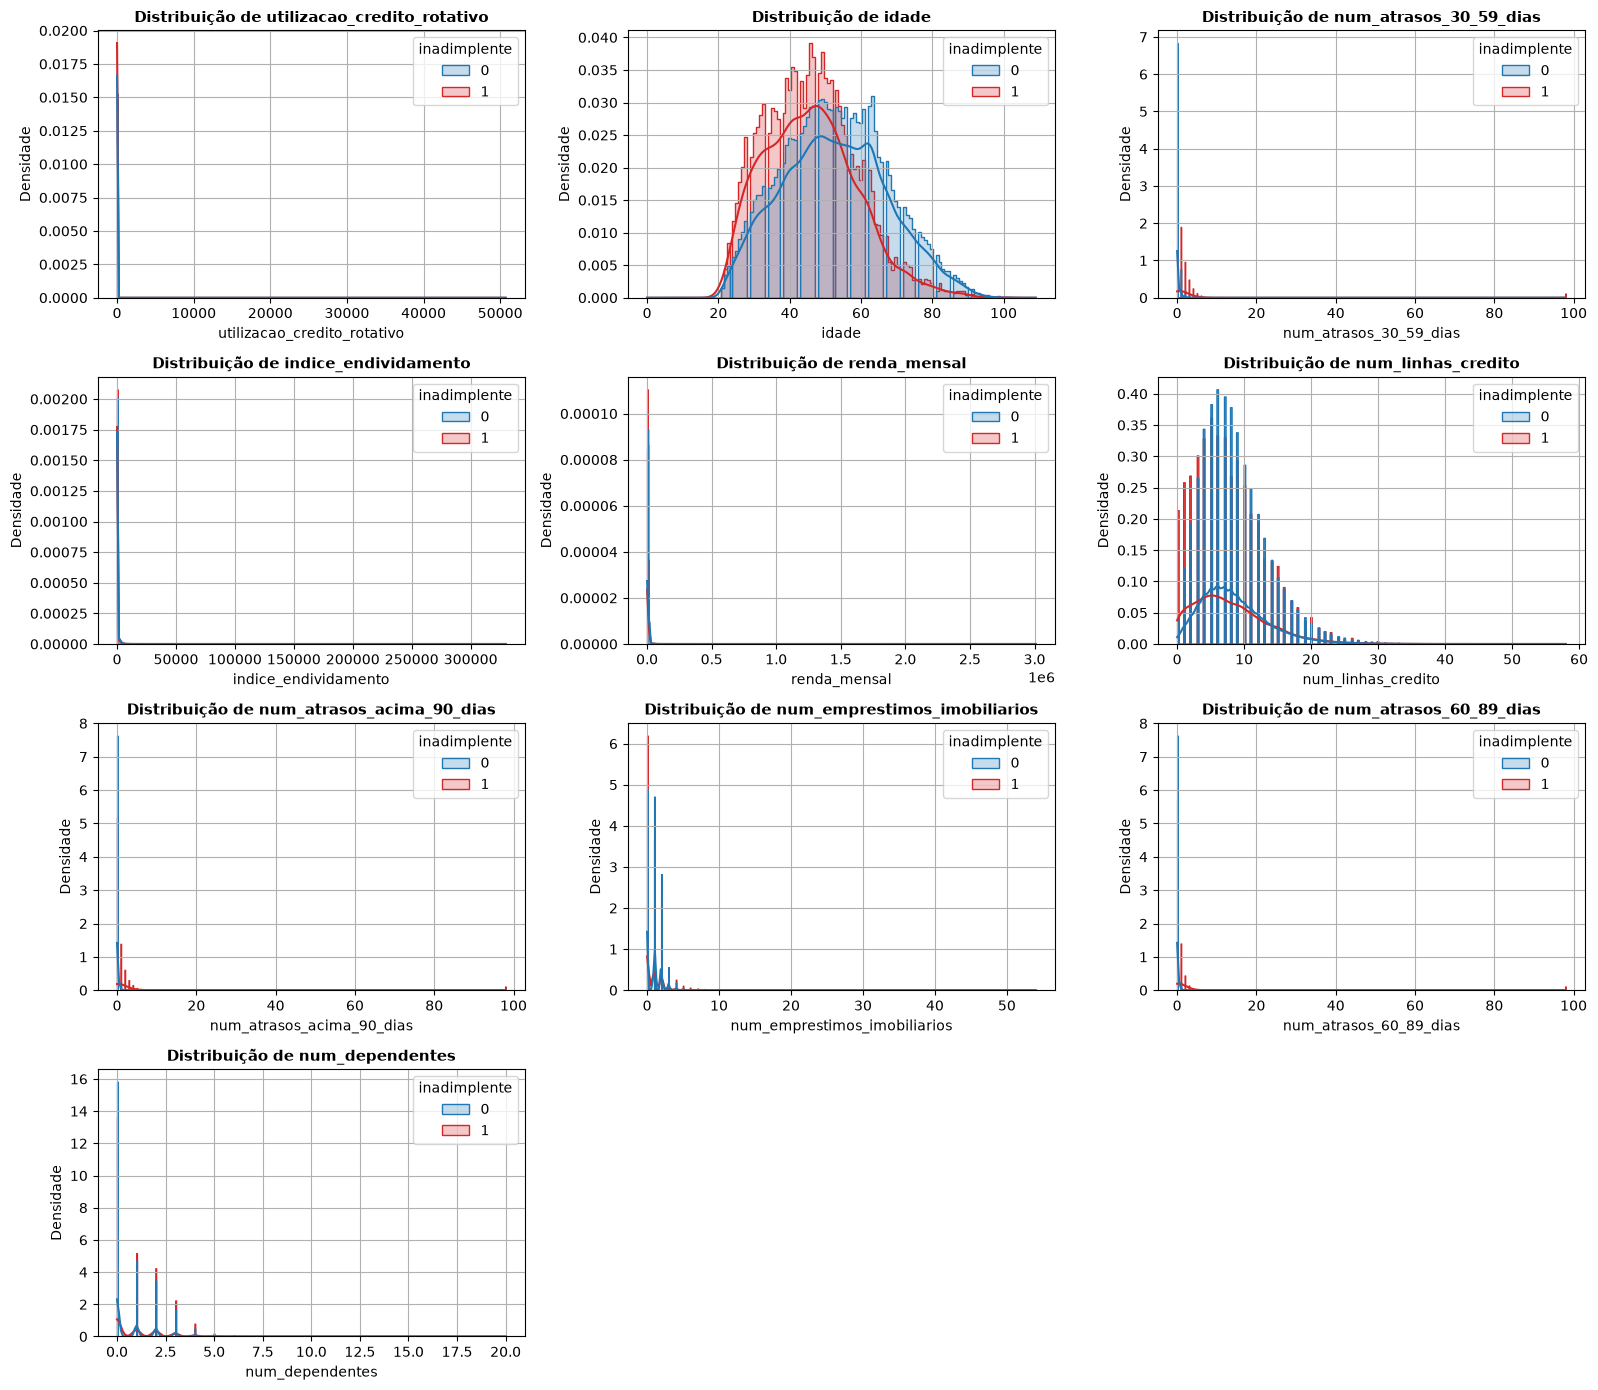

In [5]:
fig, ax = plt.subplots(4, 3, figsize=(16, 14))
ax_flat = ax.flatten()

# Remove IDs e a própria coluna alvo da lista de variáveis para o eixo
list_to_plot = [col for col in df.columns if col not in ['id', target]][:12]

for i, col in enumerate(list_to_plot):
    sns.histplot(
        data=df,
        x=col,
        hue=target,
        kde=True,              # Curva suave sobreposta
        element="step",        # Linhas em degrau evitam blocos opacos se tapando
        stat="density",        # Normaliza por densidade para comparar formatos
        common_norm=False,     # Não deixa a classe majoritária esmagar a minoritária
        palette={0: '#1f77b4', 1: '#d62728'},  # Azul para 0 (False), Vermelho para 1 (True)
        ax=ax_flat[i]
    )
    
    ax_flat[i].set_title(f"Distribuição de {col}", fontsize=11, fontweight='bold')
    ax_flat[i].set_xlabel(col)
    ax_flat[i].set_ylabel("Densidade")

# Oculta eixos sobressalentes
for j in range(len(list_to_plot), len(ax_flat)):
    fig.delaxes(ax_flat[j])

plt.tight_layout()
plt.show()

In [6]:
df_false = df[df[target] == 0] # Adimplentes
df_true = df[df[target] == 1]  # Inadimplentes

list_to_plot = [col for col in df.columns if col not in ['id', target]][:12]

print(' ')
for i in range(len(list_to_plot)):
    frac = (df_true[list_to_plot[i]].mean() / (df_true[list_to_plot[i]].mean()+df_false[list_to_plot[i]].mean()))*100
    print(f'Inadimplência Sem/Com: {list_to_plot[i]}  ->  {frac:.0f}%')

# df.groupby(target).agg('indice_endividamento','idade')

 
Inadimplência Sem/Com: utilizacao_credito_rotativo  ->  41%
Inadimplência Sem/Com: idade  ->  47%
Inadimplência Sem/Com: num_atrasos_30_59_dias  ->  90%
Inadimplência Sem/Com: indice_endividamento  ->  45%
Inadimplência Sem/Com: renda_mensal  ->  45%
Inadimplência Sem/Com: num_linhas_credito  ->  48%
Inadimplência Sem/Com: num_atrasos_acima_90_dias  ->  94%
Inadimplência Sem/Com: num_emprestimos_imobiliarios  ->  49%
Inadimplência Sem/Com: num_atrasos_60_89_dias  ->  94%
Inadimplência Sem/Com: num_dependentes  ->  56%


### Alguns insights da relação entre variáveis

**inadimplência** 
- Pessoas sem inadimplência usam mais o crédito (cerca 59% a mais) que pessoas com inadimplência;
- A idade indica que maiores idades apresentam menor inadimplência (~53 anos em relação a ~46 anos);
- Dentre os atrasos para pagamentos, temos que:
    - Número de atrasos entre 30 - 59 dias: 90% clientes inadimplentes
    - Número de atrasos entre 60 - 89 dias: 93% clientes inadimplentes
    - Número de atrasos acima de 90 dias: 94% clientes inadimplentes
- O índice de endividamento é maior para pessoas inadimplentes;
- A renda mensal também é maior para cliente adimplentes (cerca de 55%), o que pode indicar uma correlação do índice de endividamento e contribuir para maior adimplência;
- O número de linhas de crédito é levemente maior para clientes inadimplentes (~2% dos clientes ou cerca de 0,6x);
- O número de empréstimos parece não afetar tanto, 51% dos clientes com empréstimos imobiliários são adimplentes;
- O número de dependentes de clientes adimplentes é menor (44%) em relação ao número de dependentes de clientes inadimplentes (56%).
---

In [7]:
print("=" * 70)
print("1. DISTRIBUIÇÃO DAS VARIÁVEIS")
print("=" * 70)
print(df[variaveis].describe().T)

1. DISTRIBUIÇÃO DAS VARIÁVEIS
                                 count    mean      std  min     25%     50%     75%        max
utilizacao_credito_rotativo  150000.00    6.05   249.76 0.00    0.03    0.15    0.56   50708.00
idade                        150000.00   52.30    14.77 0.00   41.00   52.00   63.00     109.00
num_atrasos_30_59_dias       150000.00    0.42     4.19 0.00    0.00    0.00    0.00      98.00
indice_endividamento         150000.00  353.01  2037.82 0.00    0.18    0.37    0.87  329664.00
renda_mensal                 120269.00 6670.22 14384.67 0.00 3400.00 5400.00 8249.00 3008750.00
num_linhas_credito           150000.00    8.45     5.15 0.00    5.00    8.00   11.00      58.00
num_atrasos_acima_90_dias    150000.00    0.27     4.17 0.00    0.00    0.00    0.00      98.00
num_emprestimos_imobiliarios 150000.00    1.02     1.13 0.00    0.00    1.00    2.00      54.00
num_atrasos_60_89_dias       150000.00    0.24     4.16 0.00    0.00    0.00    0.00      98.00
num_depend

### Primeiras Impressões:

* eu esperava que *utilizacao_credito_rotativo* seria um valor no intervalo [0, 1] por se tratar da razão uso/limite, mas claramente há valores extremos!!
    * investigar o que são esse valore extremos e se há alguma relação aparente com o target

* *idade* possui um único valor que é erro, cuja idade é 0. podemos descartar sem preocupação

* *indice_endividamento* é a razão passivo/total, então quanto maior esse índice, mais arriscado um cliente (está endividado)

* *num_linhas_credito* e *num_emprestimos_imobiliarios* possuem valores muito altos, como 54 e 58. seriam flags?
    * investigar o que são esse valore extremos e se há alguma relação aparente com o target

* os atrasos claramente possuem flags (96 e 98). quantos são esses registros? carregam informação do target?

* *num_dependentes* faz sentido ter valores altos como 20??


## utilizacao_credito_rotativo

In [20]:
sem_uso_credito = (df['utilizacao_credito_rotativo'] == 0)

print(f"\nsem_uso_credito:\n"
      f"{sem_uso_credito.sum()} registros "
      f"({sem_uso_credito.mean():.2%})")

print(f"\n{'=' * 70}")
print("Distribuição da variável alvo (inadimplente) para registros sem uso de crédito rotativo")
print(df[sem_uso_credito][target].value_counts(normalize=True))

# a proporção se manteve praticamente a mesma, indicando que o uso de crédito rotativo não é um fator determinante para inadimplência.


sem_uso_credito:
10878 registros (7.25%)

Distribuição da variável alvo (inadimplente) para registros sem uso de crédito rotativo
inadimplente
0   0.97
1   0.03
Name: proportion, dtype: float64


Renda Total (Usa o Crédito - True): R$ 3,440.00
Renda Total (Não Usar o Crédito - False): R$ 2,900.00
Proporção False/True: 0.84



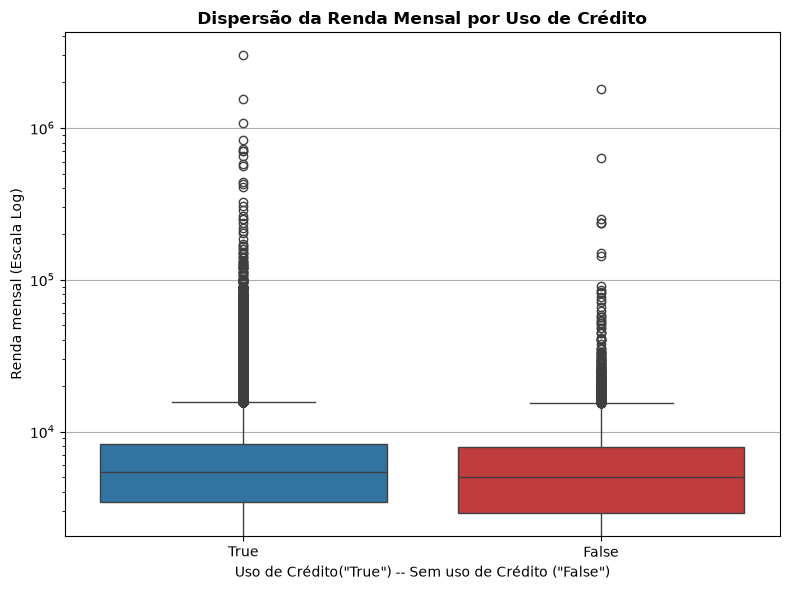

In [54]:
# count_true = df.loc[sem_uso_credito,'renda_mensal'].sum()
# count_false = df.loc[~sem_uso_credito,'renda_mensal'].sum()

# print(f'\n{70*'='}')
# print('Utilização do Crédito Rotativo')
# print(f'True: {count_true} e False: {count_false}')
# print(f'Relação entre False/True: {(count_false/count_true)}')

df['sem_uso_credito'] = (df['utilizacao_credito_rotativo'] != 0).astype(str)

# True -> Usa o crédito (> 0) e False -> Não Usa o crédito (= 0)

# 2. Faz as somas (agora filtrando pelo texto)
renda_true = df.loc[df['sem_uso_credito'] == 'True', 'renda_mensal'].quantile(0.25)
renda_false = df.loc[df['sem_uso_credito'] == 'False', 'renda_mensal'].quantile(0.25)

print(f"Renda Total (Usa o Crédito - True): R$ {renda_true:,.2f}")
print(f"Renda Total (Não Usar o Crédito - False): R$ {renda_false:,.2f}")
print(f"Proporção False/True: {(renda_false / renda_true):.2f}\n")

# 3. Gráfico boxplot
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df, 
    x='sem_uso_credito', 
    y='renda_mensal',
    hue='sem_uso_credito', # Seaborn atual exige hue quando usamos palette
    palette={'True': '#1f77b4', 'False': '#d62728'}, # Agora as chaves estão entre aspas!
    legend=False # Oculta a legenda redundante
)

plt.yscale('log')
plt.title('Dispersão da Renda Mensal por Uso de Crédito', fontweight='bold')
plt.xlabel('Uso de Crédito("True") -- Sem uso de Crédito ("False")')
plt.ylabel('Renda mensal (Escala Log)')

plt.tight_layout()
plt.show()

In [81]:
renda_true = df.loc[df['sem_uso_credito'] == 'True', 'renda_mensal'].describe()
renda_false = df.loc[df['sem_uso_credito'] == 'False', 'renda_mensal'].describe() # posso usar o quantile para obter o percentis


renda_mensal = pd.DataFrame([renda_true,renda_false])
renda_mensalT = renda_mensal.T
renda_mensalT.columns = ['Usa (True)','Não Usa (False)']
print(renda_mensalT)

       Usa (True)  Não Usa (False)
count   112398.00          7871.00
mean      6682.13          6500.11
std      13608.28         22744.36
min          0.00             0.00
25%       3440.00          2900.00
50%       5416.00          5000.00
75%       8280.00          7867.50
max    3008750.00       1794060.00


Apenas 3% dos clientes que não usam o crédito rotativo apresenta inadimplência. A empresa pode aproveitar esses caso de não uso do crédito para fornecer propagandas e promoções para fomentar esse uso.

A maior parte dos clientes utilizam o crédito rotativo (~92.75%), enquanto apenas 7.25% não usam. Dentre esses dois grupos, podemos notar que a renda mensal dos clientes é estatisticamente maior para quem usa o crédito (varia entre 8% a 18%). É interessante que as pessoas que não usam o crédito apresentam renda mais dispersa (maior desigualdade), até 2x mais.

Além disso, os clientes que usam o crédito apresentam maior número com renda mensal que ultrapassa o limite do boxplot (1,5x o tamanho da caixa, cerca de R$15.000) com alguns clientes ultrapassando R$1.000.000.

In [83]:
# uma parte relevante dos clientes que usam crédito rotativo apresentam valores maiores que 1

anomalia_credito_rotativo = (df['utilizacao_credito_rotativo'] > 1)

print(f"\nutilizacao_credito_rotativo > 1: "
      f"{anomalia_credito_rotativo.sum()} registros "
      f"({anomalia_credito_rotativo.mean():.2%})")


utilizacao_credito_rotativo > 1: 3321 registros (2.21%)


In [84]:
print("\nDistribuição do target (inadimplente) para registros com e sem anomalia de crédito rotativo:\n")
print("\n--- Geral ---")
print(df[target].value_counts(normalize=True))
print("\n--- Com anomalia ---")
print(df[anomalia_credito_rotativo][target].value_counts(normalize=True))
print("\n--- Sem anomalia ---")
print(df[~anomalia_credito_rotativo][target].value_counts(normalize=True))


Distribuição do target (inadimplente) para registros com e sem anomalia de crédito rotativo:


--- Geral ---
inadimplente
0   0.93
1   0.07
Name: proportion, dtype: float64

--- Com anomalia ---
inadimplente
0   0.63
1   0.37
Name: proportion, dtype: float64

--- Sem anomalia ---
inadimplente
0   0.94
1   0.06
Name: proportion, dtype: float64


In [ ]:
df.groupby(target).agg({'utilizacao_credito_rotativo': 'median'})

#### anomalia do credito rotativo claramente carrega informação sobre o target!!!

In [ ]:
medianas = df.groupby(anomalia_credito_rotativo)['renda_mensal'].median()

print(f"Sem anomalia: R$ {medianas[False]:,.2f}")
print(f"Com anomalia: R$ {medianas[True]:,.2f}")

## indice_endividamento

In [ ]:
df.groupby(target).agg({'indice_endividamento': 'median'})
# clientes inadimplentes possuem um índice de endividamento maior do que clientes adimplentes, o que é esperado.

In [ ]:
endividados = (df['indice_endividamento'] > 1)

df[endividados].shape[0]
# cerca de 1/5 dos clientes possuem um índice de endividamento maior do que 1, o que indica que eles possuem mais dívidas do que renda mensal.
# será??

In [ ]:
print(df[endividados][target].value_counts(normalize=True))

df[endividados].groupby(target).agg({'renda_mensal': 'median'})

In [ ]:
print(df[~endividados][target].value_counts(normalize=True))

df[~endividados].groupby(target).agg({'renda_mensal': 'median'})

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df[df[target] == 0]['renda_mensal'],
    df[df[target] == 0]['indice_endividamento'],
    alpha=0.25,
    color='green',
    label='Target 0'
)

plt.scatter(
    df[df[target] == 1]['renda_mensal'],
    df[df[target] == 1]['indice_endividamento'],
    alpha=0.25,
    color='red',
    label='Target 1'
)

plt.xlim(1, 1e5)
plt.ylim(0, 10)

plt.xlabel('Renda mensal')
plt.ylabel('Índice de endividamento')
plt.title('Renda mensal vs. Índice de endividamento')
plt.legend()

plt.show()

### já conseguimos ter uma noção de como renda e endividamento se relacionam para identificar targets

In [ ]:
df[['renda_mensal', 'indice_endividamento']].corr(method='spearman')

## num_linhas_credito

In [ ]:
df.groupby(target).agg({'num_linhas_credito': 'median'})

### pessoas com menos linhas de crédito parecem ser mais arriscadas??

In [ ]:
print('Proporção de inadimplentes em grupos com menos de 4 linhas de crédito:')
print(df[df['num_linhas_credito'] < 4][target].value_counts(normalize=True))
# cerca de 13% da base

print('\nProporção de inadimplentes em grupos com 4 ou mais linhas de crédito:')
print(df[df['num_linhas_credito'] >= 4][target].value_counts(normalize=True))

In [ ]:
bins = np.arange(
    df['num_linhas_credito'].min(),
    df['num_linhas_credito'].max() + 1,
    1
)

df[df[target] == 1]['num_linhas_credito'].hist(
    bins=bins,
    density=True,
    color='red',
    alpha=0.5,
    label='inadimplente'
)

df[df[target] == 0]['num_linhas_credito'].hist(
    bins=bins,
    density=True,
    color='green',
    alpha=0.5,
    label='adimplente'
)

plt.legend()
plt.xlabel('Número de linhas de crédito')
plt.ylabel('Densidade')
plt.show()

#### talvez cruzar essa info com outra feature possa revelar algo sobre o target

* a princípio, ter menos linhas de crédito tornam um cliente mais arriscado, mas talvez a renda possa influenciar
    * poucas linhas de crédito mas uma alta renda pode tornar o cliente menos arriscado
    * poucas linhas de crédito mas com alta renda pode tornar o cliente mais arriscado

    

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df[df[target] == 0]['renda_mensal'],
    df[df[target] == 0]['num_linhas_credito'],
    alpha=0.25,
    color='green',
    label='Target 0'
)

plt.scatter(
    df[df[target] == 1]['renda_mensal'],
    df[df[target] == 1]['num_linhas_credito'],
    alpha=0.25,
    color='red',
    label='Target 1'
)

plt.xlim(1, 1e5)

plt.xlabel('Renda mensal')
plt.ylabel('Número de linhas de crédito')
plt.title('Renda mensal vs. Número de linhas de crédito')
plt.legend()

plt.show()

## num_emprestimos_imobiliarios

In [ ]:
# maioria dos registros possuem até 2 emprestimos imobiliários
print(df['num_emprestimos_imobiliarios'].describe())
print('_'*70)
# qual a proporção de registros acima de 2 emprestimos imobiliários e qual a proporção de inadimplentes nesses registros
print('\nproporção de registros com mais de 2 empréstimos imobiliários:')
print(df[df['num_emprestimos_imobiliarios'] > 2].shape[0] / df.shape[0])
print('\nproporção de inadimplentes nesses registros:')
print(df[df['num_emprestimos_imobiliarios'] > 2][target].value_counts(normalize=True))
print('_'*70)

print('\nproporção de registros com 2 ou menos empréstimos imobiliários:')
print(df[df['num_emprestimos_imobiliarios'] <= 2].shape[0] / df.shape[0])
print('\n proporção de inadimplentes nesses registros:')
print(df[df['num_emprestimos_imobiliarios'] <= 2][target].value_counts(normalize=True))

print('_'*70)
print('\nproporção de registros com nenhuma empréstimo imobiliário:')
print(df[df['num_emprestimos_imobiliarios'] == 0].shape[0] / df.shape[0])
print('\nproporção de inadimplentes nesses registros:')
print(df[df['num_emprestimos_imobiliarios'] == 0][target].value_counts(normalize=True)) 

## atrasos

In [ ]:
colunas_atraso = [
    "num_atrasos_30_59_dias",
    "num_atrasos_60_89_dias",
    "num_atrasos_acima_90_dias",
]
print("Valores mais frequentes nas colunas de atraso (checar códigos especiais):")
for col in colunas_atraso:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().sort_index(ascending=False).head(5))

### claramente 98 e 96 são flags, mas flags de quê?? são coincidentes?

In [ ]:
print('flag de atraso (30-59 dias) = 96:')
print(df[df['num_atrasos_30_59_dias'] == 96][['num_atrasos_30_59_dias', 'num_atrasos_60_89_dias', 'num_atrasos_acima_90_dias']].describe().T)

print('\n\nflag de atraso (30-59 dias) = 98:')
print(df[df['num_atrasos_30_59_dias'] == 98][['num_atrasos_30_59_dias', 'num_atrasos_60_89_dias', 'num_atrasos_acima_90_dias']].describe().T)

### sim, são coincidentes --> menos trabalho :)

In [ ]:
atrasos_flag = df['num_atrasos_30_59_dias'].isin([96, 98]) # (como são coincidentes, tanto faz qual coluna usar)

print(df[atrasos_flag][target].value_counts(normalize=True))
print('\nquantidade de registros:', df[atrasos_flag].shape[0])


# carrega bastante informação sobre o target!!! cerca de metade desses registros são inadimplentes, enquanto na base geral a proporção é de apenas 7,5%

In [ ]:
df[~atrasos_flag][target].value_counts(normalize=True) # sem a flag, a proporção de inadimplentes é igual a da base

In [ ]:
df[colunas_atraso + [target]].corr(method='spearman')

In [ ]:
resultados = []

for col in colunas_atraso:

    aux = (
        df.assign(
            teve_atraso=df[col] > 0
        )
        .groupby('teve_atraso')[target]
        .agg(
            proporcao_inadimplentes='mean',
            registros='count'
        )
    )

    aux['proporcao_inadimplentes'] *= 100
    aux['variavel'] = col

    resultados.append(aux.reset_index())

analise = pd.concat(resultados, ignore_index=True)

analise

### forte relação entre ter atraso e ser inadimplente

## num_dependentes

In [ ]:
df['num_dependentes'].value_counts()
# a partir de 5 dependentes, quase não observamos registros. se dividirmos a base em dois grupos (até 4 dependentes e mais de 4 dependentes), como se comporta a taxa de inadimplência?

In [ ]:
ate_5_dependentes = (df['num_dependentes'] <= 4)
mais_5_dependentes = (df['num_dependentes'] > 4)

print("\nDistribuição do target (inadimplente) para registros com até 4 dependentes e mais de 4 dependentes:\n")
print("\n--- Até 4 dependentes ---", df[ate_5_dependentes].shape[0], 'registros')
print(df[ate_5_dependentes][target].value_counts(normalize=True))
print("\n--- Mais de 4 dependentes ---", df[mais_5_dependentes].shape[0], 'registros')
print(df[mais_5_dependentes][target].value_counts(normalize=True))


In [ ]:
bins = np.arange(
    df['num_dependentes'].min(),
    df['num_dependentes'].max() + 1,
    1
)

df[df[target] == 1]['num_dependentes'].hist(
    bins=bins,
    density=True,
    color='red',
    alpha=0.5,
    label='inadimplente'
)

df[df[target] == 0]['num_dependentes'].hist(
    bins=bins,
    density=True,
    color='green',
    alpha=0.5,
    label='adimplente'
)

plt.legend()
plt.xlabel('Número de dependentes')
plt.ylabel('Densidade')
plt.show()

### essa é uma das features que possui Nans... será que carregam informação?

In [ ]:
dependentes_nans = df['num_dependentes'].isna()

print("Distribuição do target para registros com valores ausentes em 'num_dependentes':")
print('total de', dependentes_nans.sum(), 'registros\n')
print(df[dependentes_nans][target].value_counts(normalize=True))

# proporçao de inadimplentes para registros com valores ausentes é próximo à proporçao da base geral, indicando que a ausência de informação sobre o número de dependentes não está relacionada à inadimplência.


## renda_mensal

In [ ]:
df['renda_mensal'].describe()

# é uma feature muito variada. além disso, pode ser que valores puros nao informem nada, afinal, um cliente alta renda nem sempre é um cliente de baixo risco. talvez seja interessante criar uma nova feature a partir da renda (normalizar a renda em relação ao número de dependentes, por exemplo)

In [ ]:
df.groupby(target).agg({'renda_mensal': 'median'})
# inadimplentes tem renda mediana de 4.500, enquanto adimplentes tem renda mediana de 5.500. portanto, não há indício de que a renda esteja relacionada à inadimplência.

In [ ]:
bins = [0, 1000, 2000, 3000, 4000, 5000, 7000, 10000, np.inf]

df['faixa_renda'] = pd.cut(
    df['renda_mensal'],
    bins=bins
)

analise = (
    df.groupby('faixa_renda', observed=True)[target]
      .value_counts(normalize=True)
      .unstack(fill_value=0)
)

analise

In [ ]:
df['decil_renda'] = pd.qcut(
    df['renda_mensal'],
    q=10,
    duplicates='drop'
)

analise = (
    df.groupby('decil_renda', observed=True)[target]
      .value_counts(normalize=True)
      .unstack(fill_value=0)
)

analise[1] * 100

In [ ]:
bins = np.arange(
    0,
    df['renda_mensal'].quantile(0.99) + 1000,
    1000
)

plt.figure(figsize=(10, 6))

df[df[target] == 0]['renda_mensal'].hist(
    bins=bins,
    density=True,
    alpha=0.5,
    color='green',
    label='Adimplente'
)

df[df[target] == 1]['renda_mensal'].hist(
    bins=bins,
    density=True,
    alpha=0.5,
    color='red',
    label='Inadimplente'
)

plt.xlabel('Renda mensal')
plt.ylabel('Densidade')
plt.title('Distribuição de renda por status de crédito')
plt.legend()

plt.show()

In [ ]:
from scipy.stats import ks_2samp

renda_0 = df.loc[df[target] == 0, 'renda_mensal'].dropna()
renda_1 = df.loc[df[target] == 1, 'renda_mensal'].dropna()

resultado = ks_2samp(renda_0, renda_1)

print(f"KS: {resultado.statistic:.4f}")
print(f"p-value: {resultado.pvalue:.4f}")

### renda_mensal é uma das features que possui Nans... vamos verificar se há informação sobre o target

In [ ]:
renda_nan = df['renda_mensal'].isna()

print('quantidade de registros com renda ausente:', renda_nan.sum())
df.groupby(df['renda_mensal'].isna())[target].value_counts(normalize=True)

# a proporção de inadimplentes para registros com valores ausentes em 'renda_mensal' é próxima à proporção da base geral.
# ausência dessa informação não parece estar relacionada à inadimplência.
# mas novamente, é 1%... talvez seja significativo sim, como avaliar??

## Avaliando porcentagem de targets por quantil das variáveis

In [ ]:
print("\n" + "=" * 70)
print("3. TAXA DE INADIMPLÊNCIA POR FAIXA (QUARTIL) DE CADA VARIÁVEL")
print("=" * 70)

quantil = 4

for col in variaveis:
    print(f"\n--- {col} ---")
    try:
        faixas = pd.qcut(df[col], q=quantil, duplicates="drop")
        tabela = df.groupby(faixas, observed=True)[target].agg(
            taxa_inadimplencia="mean", qtd_clientes="count"
        )
        print(tabela)
    except ValueError as e:
        tabela = df.groupby(col, observed=True)[target].agg(
            taxa_inadimplencia="mean", qtd_clientes="count"
        )
        print(f"(não foi possível dividir em quartis: {e})")
        print("Agrupando por valor único da coluna em vez disso:")
        print(tabela)